In [1]:
import re
import pandas as pd
import glob
import os

def procesar_log_detallado(ruta_archivo):
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            texto = f.read()
    except FileNotFoundError:
        return f"Error: No se encontró el archivo {ruta_archivo}", None, None

    #Separamos el log por secciones asociadas a cada dataset
    secciones = re.split(r"\*{20,}Ejecutando prueba sobre el dataset", texto)
    
    resumen_data = []
    clases_data = []
    
    #Extraemos el nombre del método de la primera sección o del log en general si es posible
    #Buscamos la línea: Configuración: Epoch=..., Aumentado=Nombre del Método
    metodo_match_global = re.search(r"Aumentado=(.+)$", texto, re.MULTILINE)

    if metodo_match_global:
        nombre_metodo_defecto = metodo_match_global.group(1).strip().replace("Aumentado=", "")
    else:
        nombre_metodo_defecto = os.path.basename(ruta_archivo).replace(".log", "").replace("Aumentado=", "")

    for seccion in secciones[1:]:
        lineas = seccion.strip().split('\n')
        dataset_name = lineas[0].split('*')[0].strip()
        
        #Extraemos métricas
        oa_match = re.search(r"OA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        aa_match = re.search(r"AA Final:\s*([\d.]+)%\s*±\s*([\d.]+)%", seccion)
        tiempo_total_match = re.search(r"Tiempo entrenamiento total medio .*?:\s*([\d.]+)\s*s", seccion)
        tiempo_epoca_match = re.search(r"Tiempo medio por época .*?:\s*([\d.]+)\s*s", seccion)
        
        #Extraemos el método específico de esta sección (por si acaso varía, aunque en principio es siempre el mismo por log)
        metodo_match = re.search(r"Aumentado=(.+)$", seccion, re.MULTILINE)
        nombre_metodo = metodo_match.group(1).strip().replace("Aumentado=", "") if metodo_match else nombre_metodo_defecto

        if oa_match and aa_match:
            datos_dataset = {
                "Método": nombre_metodo,
                "Dataset": dataset_name,
                "OA (%)": float(oa_match.group(1)),
                "std OA (%)": float(oa_match.group(2)),
                "AA (%)": float(aa_match.group(1)),
                "std AA (%)": float(aa_match.group(2)),
                "Tiempo Total (s)": float(tiempo_total_match.group(1)) if tiempo_total_match else None,
                "Tiempo por Época (s)": float(tiempo_epoca_match.group(1)) if tiempo_epoca_match else None
            }
            resumen_data.append(datos_dataset)
            
        bloque_clases = re.search(r"ACCURACY POR CLASE:(.*?)---", seccion, re.DOTALL)
        if bloque_clases:
            matches_clase = re.findall(r"Clase (\d+):\s*([\d.]+)%", bloque_clases.group(1))
            for num_clase, valor_acc in matches_clase:
                clases_data.append({
                    "Dataset": dataset_name,
                    "Clase": f"Clase {num_clase}",
                    "Accuracy (%)": float(valor_acc)
                })
    
    if not resumen_data:
        return "No se encontraron datos válidos.", None, None

    df_resumen = pd.DataFrame(resumen_data)
    df_clases_long = pd.DataFrame(clases_data)
    df_clases_wide = df_clases_long.pivot(index='Dataset', columns='Clase', values='Accuracy (%)')
    
    stats = {
        "Métrica": ["OA Global", "AA Global", "Tiempo Total (s)", "Tiempo por Época (s)"],
        "Media": [df_resumen["OA (%)"].mean(), df_resumen["AA (%)"].mean(), df_resumen["Tiempo Total (s)"].mean(), df_resumen["Tiempo por Época (s)"].mean()],
        "Desviación": [df_resumen["OA (%)"].std(), df_resumen["AA (%)"].std(), df_resumen["Tiempo Total (s)"].std(), df_resumen["Tiempo por Época (s)"].std()]
    }
    df_stats = pd.DataFrame(stats)
    
    #Retornamos también el nombre del método para usarlo en las gráficas
    return df_resumen, df_stats, df_clases_wide, nombre_metodo_defecto

In [2]:
def imprimirResultados(ruta_carpeta):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    datos_comparacion = []

    if not archivos:
        print(f"No se encontraron archivos .log en la carpeta '{ruta_carpeta}'.")
        return []

    for archivo in archivos:
        nombre_archivo = os.path.basename(archivo).replace(".log", "")
        print(f"\n{'='*30} ARCHIVO: {nombre_archivo} {'='*30}")
        
        df_res, df_st, df_clases, nombre_metodo = procesar_log_detallado(archivo)
        
        if isinstance(df_res, pd.DataFrame):
            print("\n************* TABLA RESUMEN (OA/AA): *************")
            print(df_res.to_string(index=False))
            print("\n************* ESTADÍSTICAS GLOBALES: *************")
            print(df_st.to_string(index=False))
            
            oa_global = df_st.loc[df_st['Métrica'] == 'OA Global', 'Media'].values[0]
            aa_global = df_st.loc[df_st['Métrica'] == 'AA Global', 'Media'].values[0]
            oa_std = df_st.loc[df_st['Métrica'] == 'OA Global', 'Desviación'].values[0]
            aa_std = df_st.loc[df_st['Métrica'] == 'AA Global', 'Desviación'].values[0]
            
            t_total_medio = df_st.loc[df_st['Métrica'] == 'Tiempo Total (s)', 'Media'].values[0]
            t_epoca_medio = df_st.loc[df_st['Métrica'] == 'Tiempo por Época (s)', 'Media'].values[0]
            
            datos_comparacion.append({
                "Método": nombre_metodo,  #Usamos el nombre descriptivo extraído
                "OA Global (%)": oa_global,
                "AA Global (%)": aa_global,
                "OA Std (%)": oa_std,
                "AA Std (%)": aa_std,
                "Tiempo Total Medio (s)": t_total_medio,
                "Tiempo Época Medio (s)": t_epoca_medio
            })
        else:
            print(df_res)
        
    if datos_comparacion:
        datos_ordenados = sorted(
            datos_comparacion, 
            key=lambda x: (x["AA Global (%)"], x["OA Global (%)"]), 
            reverse=True
        )
        
        
        
        #Definimos anchos fijos para reutilizar y evitar errores de cálculo
        w_rank = 8
        w_metodo = 40 
        w_oa = 22
        w_aa = 22

        print(f"\n\n{'='*30} RESUMEN RESULTADOS {'='*30}")

        #Encabezado
        header = f"{'Ranking':<{w_rank}} | {'Método':<{w_metodo}} | {'OA Global (%) ± Std':<{w_oa}} | {'AA Global (%) ± Std':<{w_aa}}"
        print(header)
        print("-" * len(header))

        #Filas
        for i, dato in enumerate(datos_ordenados, start=1):
            oa_str = f"{dato['OA Global (%)']:.2f} ± {dato['OA Std (%)']:.2f}"
            aa_str = f"{dato['AA Global (%)']:.2f} ± {dato['AA Std (%)']:.2f}"
            
            
            print(f"#{i:<{w_rank-1}} | {dato['Método']:<{w_metodo}} | {oa_str:<{w_oa}} | {aa_str:<{w_aa}}")

        print("=" * len(header))


    return datos_comparacion

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

def graficaComparacionModelos(datos_comparacion):
    if datos_comparacion:
        # Creamos una copia para no alterar los datos originales
        df_comparacion = pd.DataFrame(datos_comparacion).copy()

        # 1. Ordenamos por AA
        if 'AA Global (%)' in df_comparacion.columns:
            df_comparacion = df_comparacion.sort_values(by='AA Global (%)', ascending=False)
        
        df_comparacion = df_comparacion.head(10)
        top_n = len(df_comparacion) # Número dinámico para el título
        
        # Reemplazar guiones bajos por espacios para el formato final
        if 'Método' in df_comparacion.columns:
            df_comparacion['Método'] = df_comparacion['Método'].str.replace('_', ' ')
        
        tiene_tiempos = "Tiempo Total Medio (s)" in df_comparacion.columns and not df_comparacion["Tiempo Total Medio (s)"].isnull().all()
        fig_size = (12, 6.5)

        #---------------------------------------------------------
        # Gráfica 1: Precisión
        #---------------------------------------------------------
        ax1 = df_comparacion.set_index('Método')[['OA Global (%)', 'AA Global (%)']].plot(
            kind='bar', color=['#1f77b4', '#ff7f0e'], alpha=0.8, figsize=fig_size, width=0.75
        )
        ax1.set_title(f'Media Precisión Global (OA y AA) - TOP {top_n}', fontsize=14, fontweight='bold', pad=15)
        ax1.set_ylabel('Precisión (%)', fontsize=11)
        ax1.set_xlabel('Métodos de Aumentado', fontsize=11, labelpad=10)
        ax1.set_ylim(80, 103) # Subimos a 103 para que las etiquetas de arriba no se corten
        
        # Rejilla sutil detrás de las barras
        ax1.set_axisbelow(True)
        ax1.grid(axis='y', linestyle='--', alpha=0.5)
        
        # AÑADIR ETIQUETAS DE TEXTO ENCIMA DE LAS BARRAS
        for container in ax1.containers:
            ax1.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8.5, fontweight='semibold')
            
        ax1.legend(["OA Global", "AA Global"], loc='upper right', frameon=True, shadow=False)
        
        plt.xticks(rotation=35, ha='right', fontsize=9.5)
        plt.tight_layout()
        plt.show() 

        #---------------------------------------------------------
        # Gráfica 2: Desviación
        #---------------------------------------------------------
        ax2 = df_comparacion.set_index('Método')[['OA Std (%)', 'AA Std (%)']].plot(
            kind='bar', color=['#2ca02c', '#d62728'], alpha=0.8, figsize=fig_size, width=0.75
        )
        ax2.set_title(f'Desviación estándar (OA y AA) - TOP {top_n}', fontsize=14, fontweight='bold', pad=15)
        ax2.set_ylabel('Variación (%)', fontsize=11)
        ax2.set_xlabel('Métodos de Aumentado', fontsize=11, labelpad=10)
        
        ax2.set_axisbelow(True)
        ax2.grid(axis='y', linestyle='--', alpha=0.5)
        
        # Etiquetas de texto para la desviación
        for container in ax2.containers:
            ax2.bar_label(container, fmt='%.2f', padding=3, fontsize=8.5, fontweight='semibold')
            
        ax2.legend(["OA Std", "AA Std"], loc='upper right', frameon=True)
        
        plt.xticks(rotation=35, ha='right', fontsize=9.5)
        plt.tight_layout()
        plt.show()

        #---------------------------------------------------------
        # Gráfica 3: Tiempos (solo si existe)
        #---------------------------------------------------------
        if tiene_tiempos:
            ax3 = df_comparacion.set_index('Método')[['Tiempo Época Medio (s)']].plot(
                kind='bar', color=['#8c564b'], alpha=0.8, figsize=fig_size, width=0.4 # Más delgada al ser barra única
            )
            ax3.set_title(f'Coste Computacional (Tiempo Medio por Época) - TOP {top_n}', fontsize=14, fontweight='bold', pad=15)
            ax3.set_ylabel('Tiempo (segundos)', fontsize=11)
            ax3.set_xlabel('Métodos de Aumentado', fontsize=11, labelpad=10)
            ax3.set_ylim(bottom=0, top=df_comparacion['Tiempo Época Medio (s)'].max() * 1.15)
            
            ax3.set_axisbelow(True)
            ax3.grid(axis='y', linestyle='--', alpha=0.5)
            
            for container in ax3.containers:
                ax3.bar_label(container, fmt='%.1fs', padding=3, fontsize=9, fontweight='semibold')
                
            ax3.legend(["Tiempo Medio por Época"], loc='upper right', frameon=True)
            
            plt.xticks(rotation=35, ha='right', fontsize=9.5)
            plt.tight_layout()
            plt.show()

## Resultados usando el aumentado de la clase minoritaria en el dataloader

In [4]:
ruta_carpeta = "Codigos_AumentadosPyTorch/resultadosAumentado_PyTorch"

datos_comparacion=imprimirResultados(ruta_carpeta)


============================== ARCHIVO: metodo_0_Sin_Aumentado ==============================

************* TABLA RESUMEN (OA/AA): *************
  Método         Dataset  OA (%)  std OA (%)  AA (%)  std AA (%)  Tiempo Total (s)  Tiempo por Época (s)
0, Flips         oitaven   95.09        0.20   91.67        0.64             53.03                0.5303
0, Flips      das_mestas   90.90        0.08   88.55        0.23             92.74                0.9274
0, Flips       eiras_dam   95.30        0.45   88.92        0.97             39.47                0.3947
0, Flips   ermidas_creek   97.89        0.08   95.83        0.40             58.16                0.5816
0, Flips ferreiras_river   91.37        0.10   78.29        1.26            130.76                1.3076
0, Flips      mera_river   90.61        0.09   74.48        4.32            151.02                1.5102
0, Flips            ulla   98.65        0.62   97.78        1.42              4.24                0.0424
0, Flips     

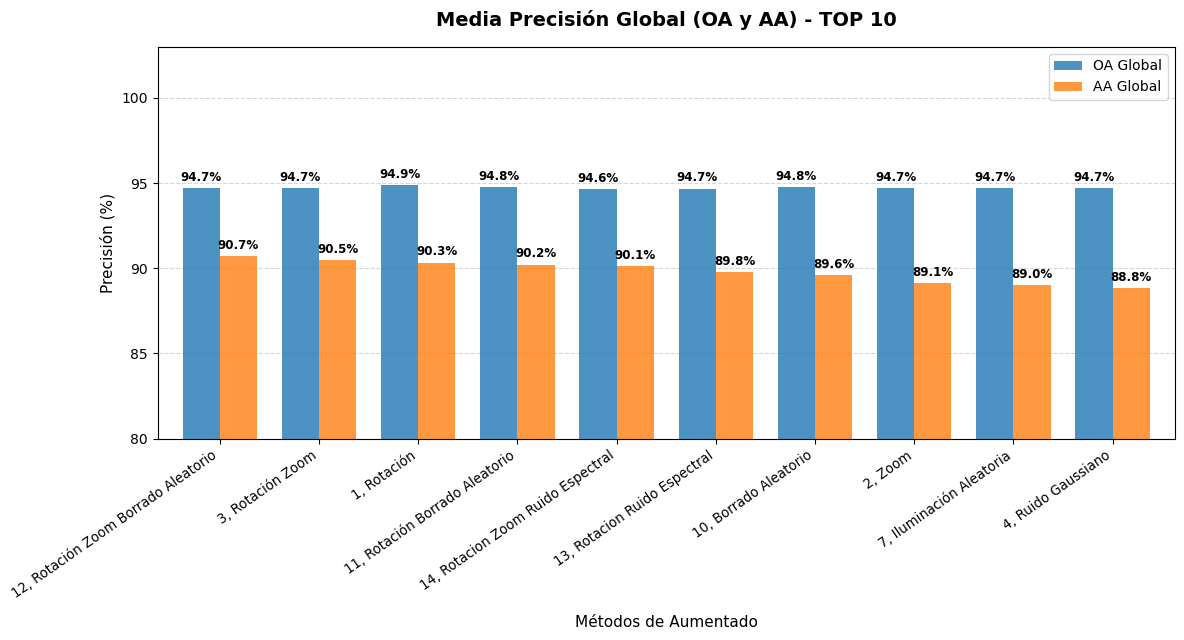

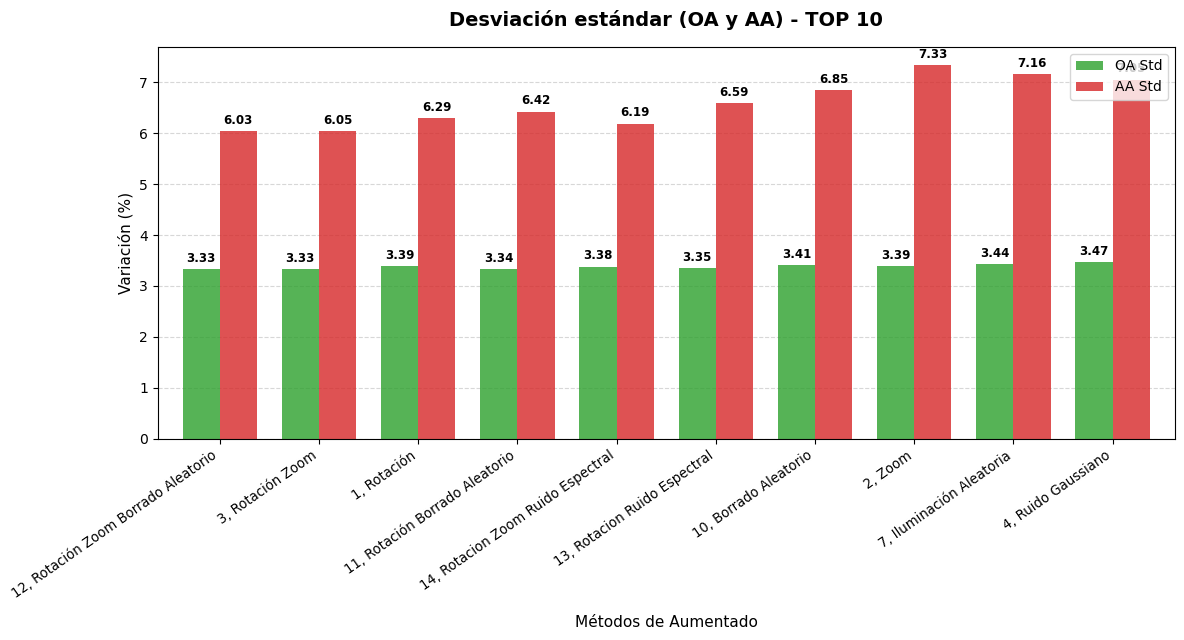

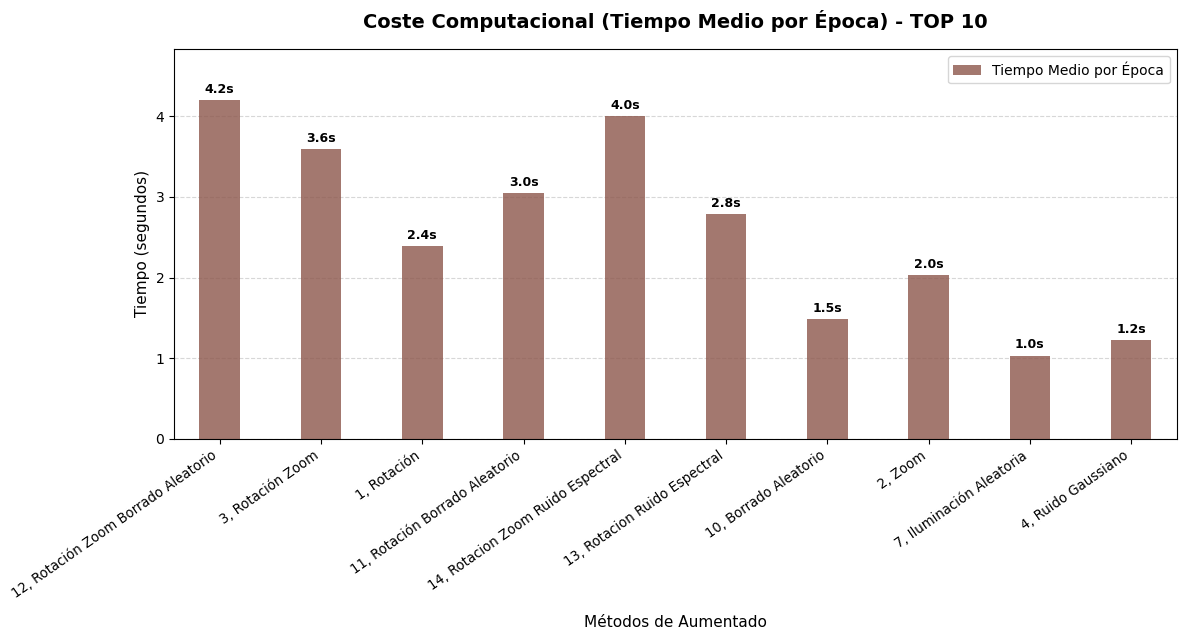

In [5]:
graficaComparacionModelos(datos_comparacion)

# Comportamiento de las distintas versiones por cada dataset

In [6]:
# DICCIONARIO GLOBAL DE COLORES
PALETA_COLORES = {
    # FASE 1:
    # CNN Básica
    "CNN_Basica": "#6baed6",                 
    "CNN_Basica_PyTorch": "#6baed6",
    "CNN_Basica_Aum": "#1f77b4",             
    "CNN_Basica_Aumento": "#1f77b4",
    
    #CutMix
    "CUTMIX": "#a1d99b",                     
    "CUTMIX_PyTorch": "#a1d99b",
    "CUTMIX_Aum": "#2ca02c",                 
    "CUTMIX_Aumento": "#2ca02c",
    
    #FMix
    "FMIX": "#c49c94",                       
    "FMIX_PyTorch": "#c49c94",
    "FMIX_Aum": "#8c564b",                   
    "FMIX_Aumento": "#8c564b",
    
    #MixUp
    "MIXUP": "#c7c7c7",                      
    "MIXUP_PyTorch": "#c7c7c7",
    "MIXUP_Aum": "#7f7f7f",                  
    "MIXUP_Aumento": "#7f7f7f",
    
    #CutMix + FMix
    "CUTMIX_FMIX": "#9edae5",                
    "CUTMIX_FMIX_PyTorch": "#9edae5",
    "CUTMIX_FMIX_Aum": "#17becf",            
    "CUTMIX_FMIX_Aumento": "#17becf",


    # FASES 3 y 4
    "VIT_Basica": "#e377c2",                
    "VIT_Basica_Aumentado": "#9467bd",       
    "VIT+CUTMIX": "#ff7f0e",                 
    "VIT+CUTMIX+FMIX": "#d62728",            

    # FASE 2
    "0, Flips": "#bcbd22",                   
    "1, Rotación": "#aec7e8",
    "3, Rotación_Zoom": "#ffbb78",
    "11, Rotación_Borrado Aleatorio": "#f7b6d2",
    "12, Rotación_Zoom_Borrado Aleatorio": "#dbdb8d"
}

Modelos seleccionados (Top 4 + inicial 0): ['12, Rotación_Zoom_Borrado Aleatorio', '3, Rotación_Zoom', '1, Rotación', '11, Rotación_Borrado Aleatorio', '0, Flips']

Generando gráfica detallada para: das_mestas...


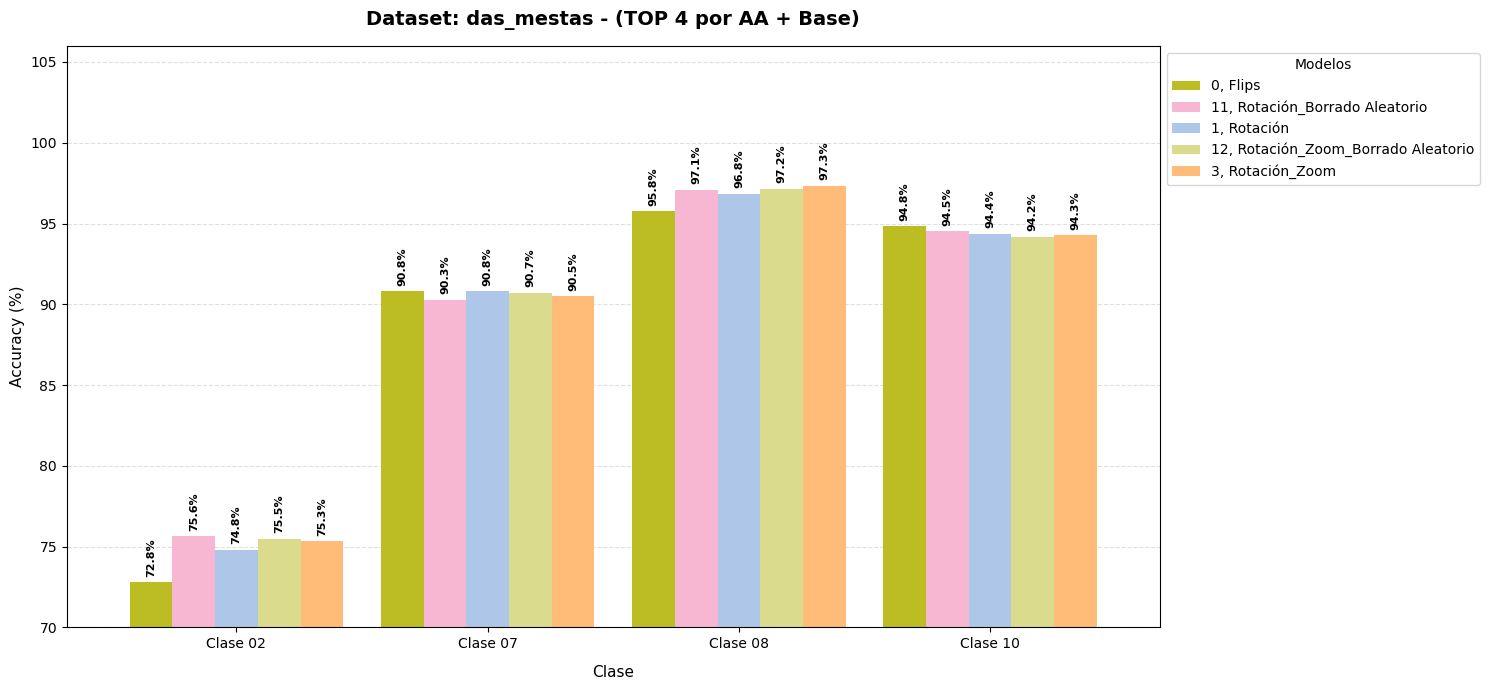


Generando gráfica detallada para: eiras_dam...


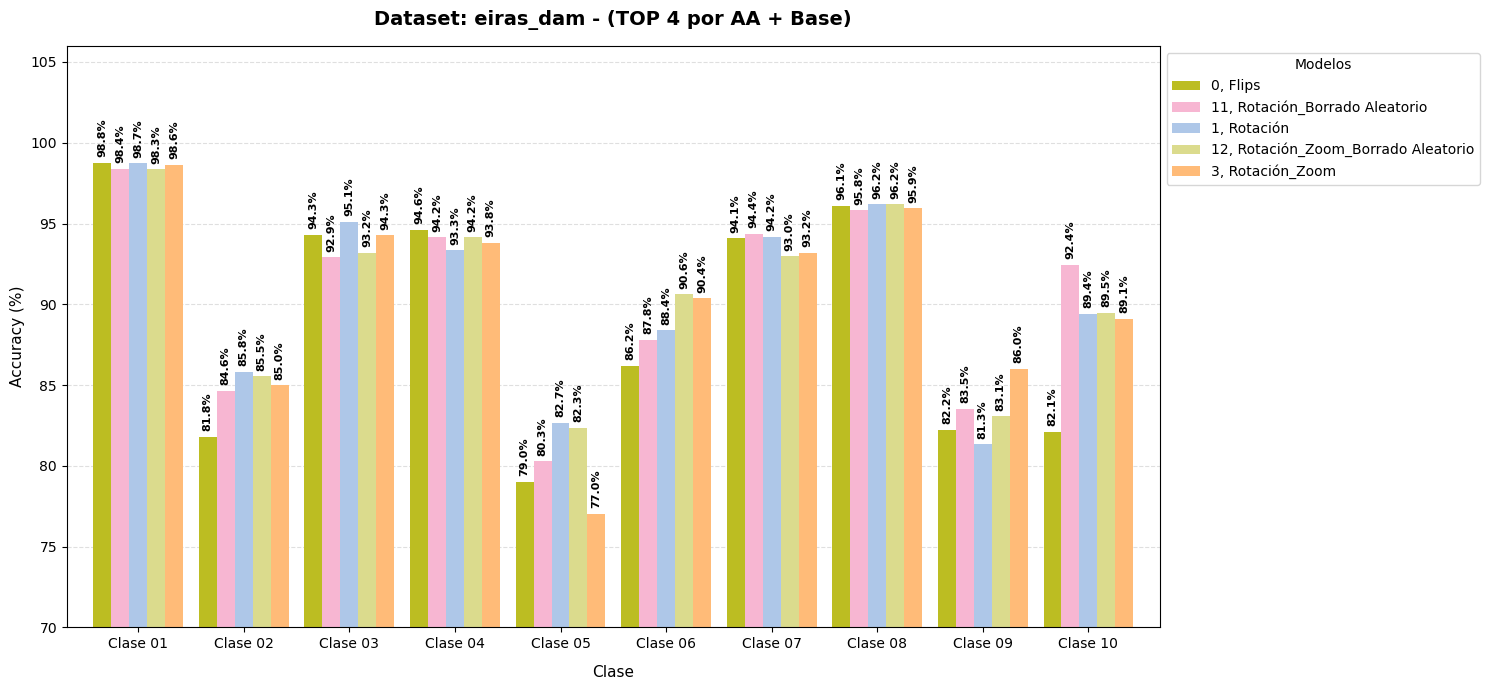


Generando gráfica detallada para: ermidas_creek...


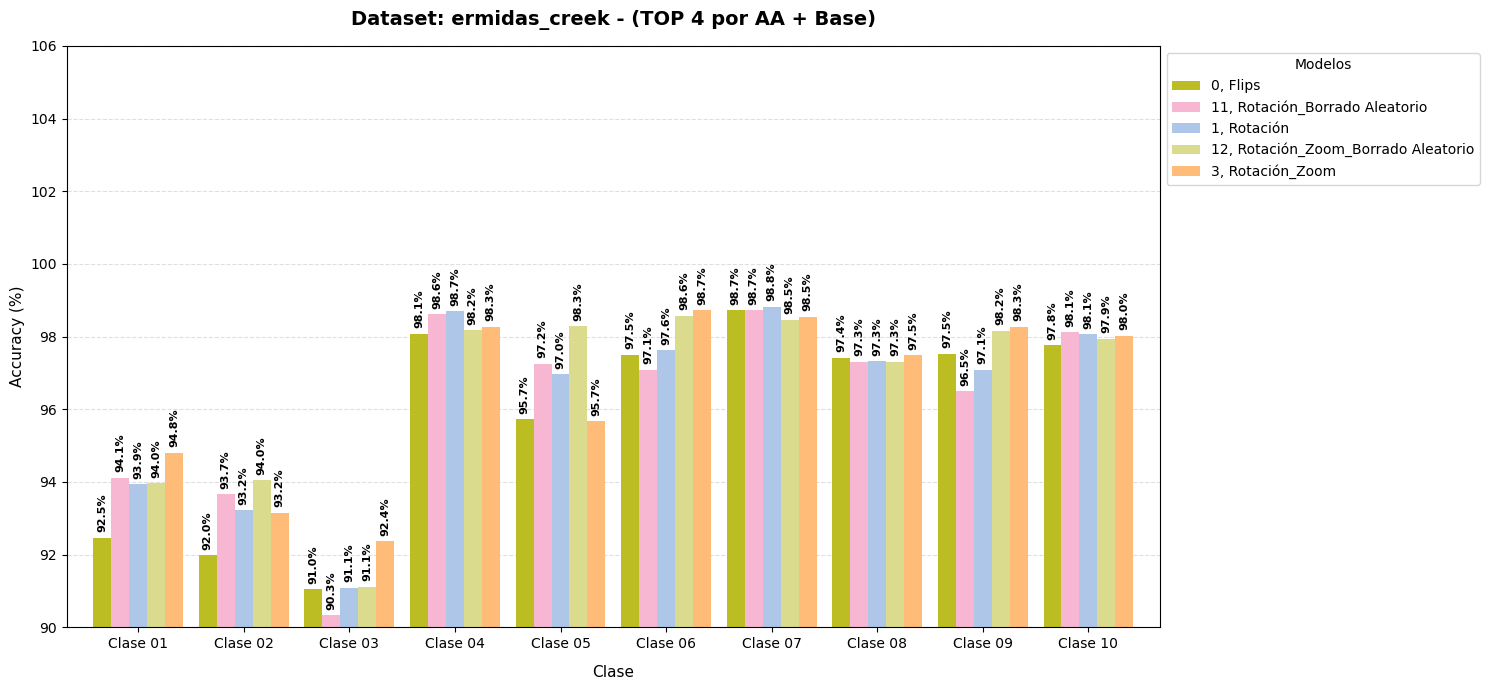


Generando gráfica detallada para: ferreiras_river...


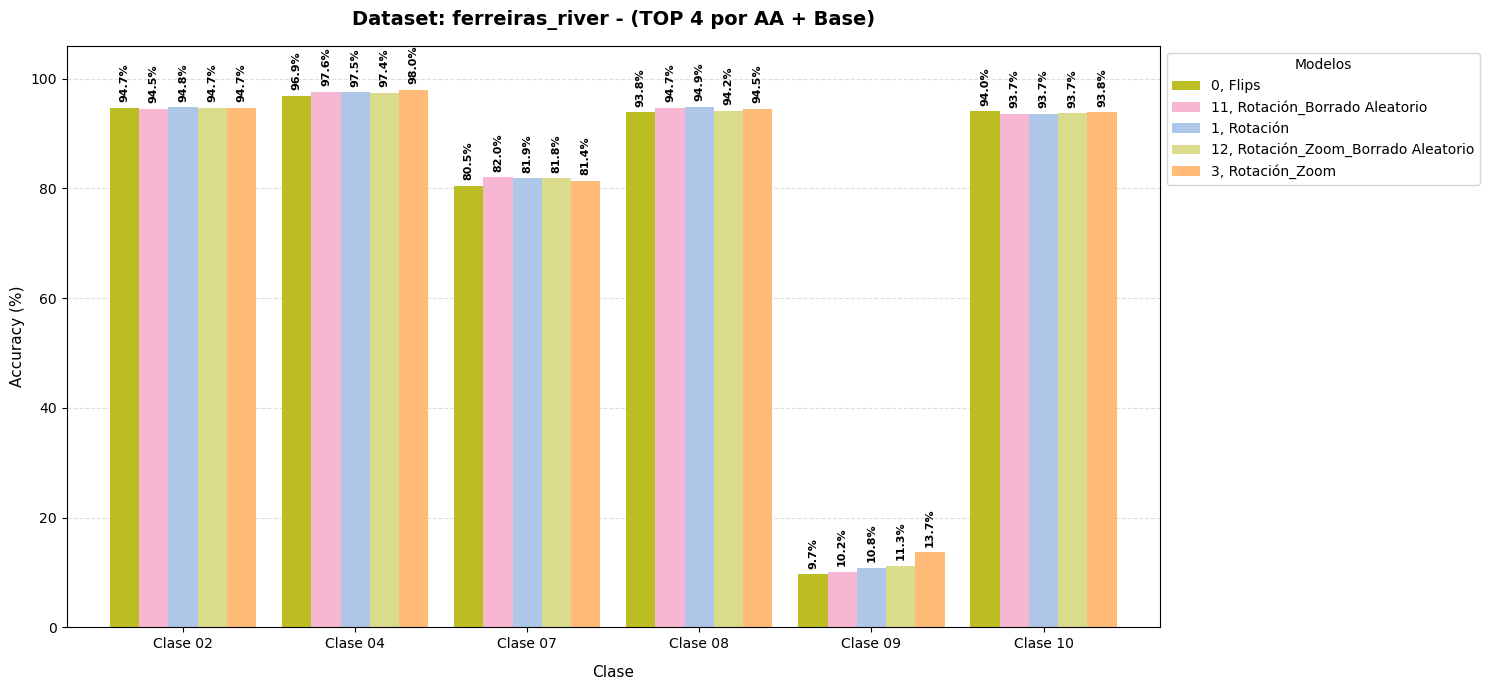


Generando gráfica detallada para: mera_river...


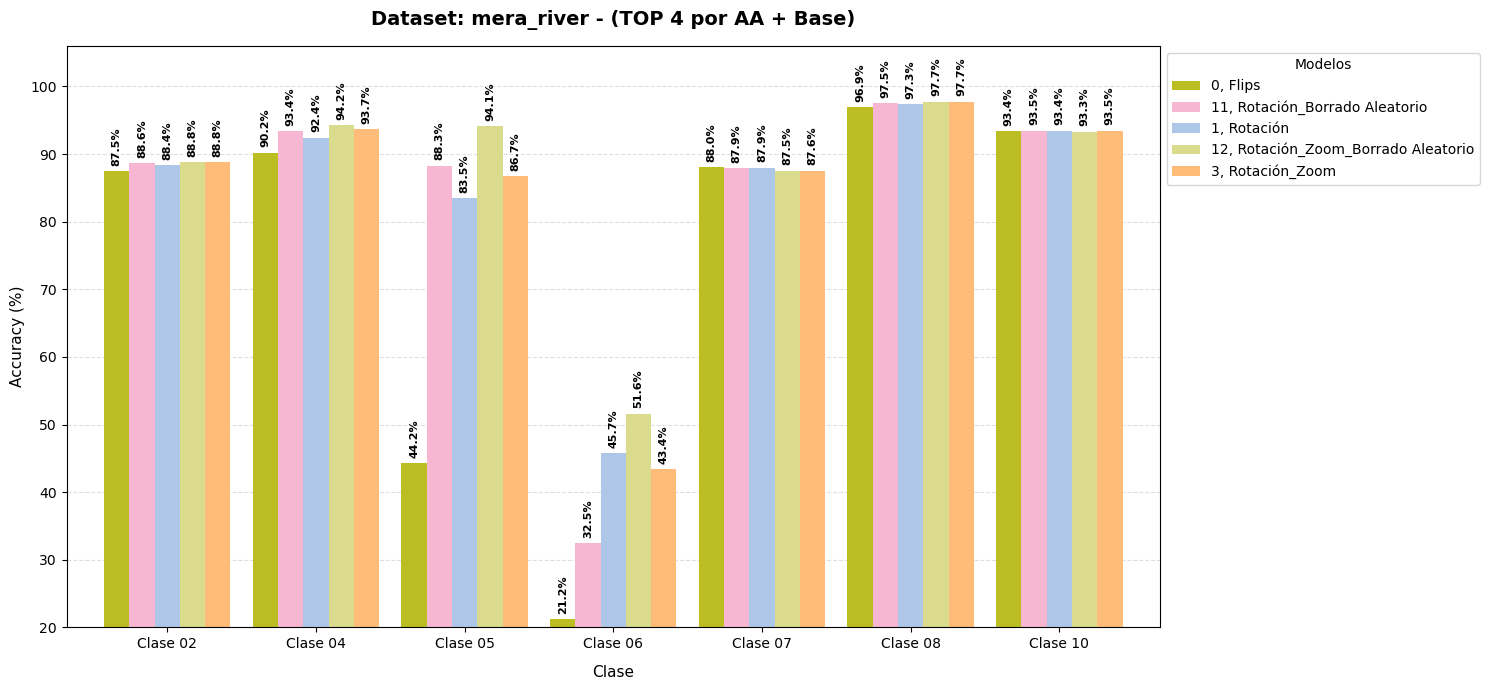


Generando gráfica detallada para: oitaven...


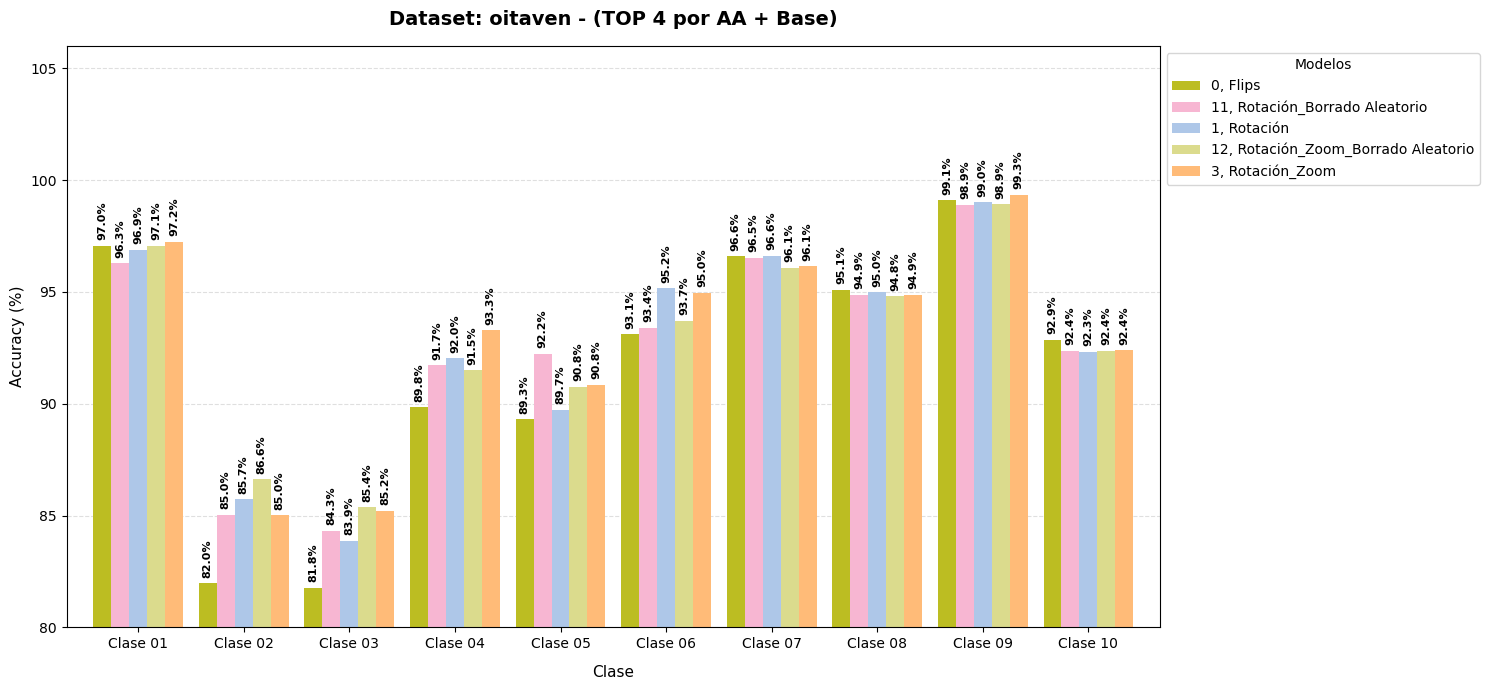


Generando gráfica detallada para: ulla...


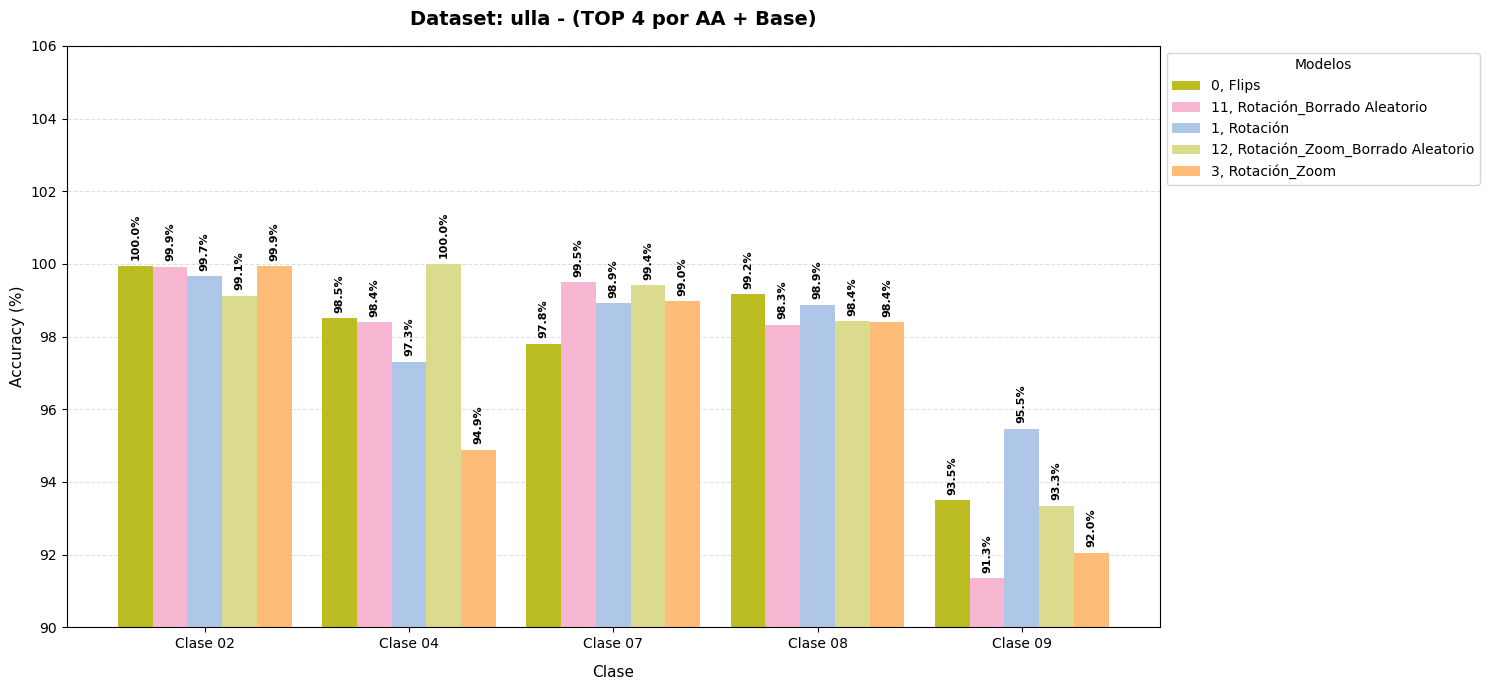


Generando gráfica detallada para: xesta...


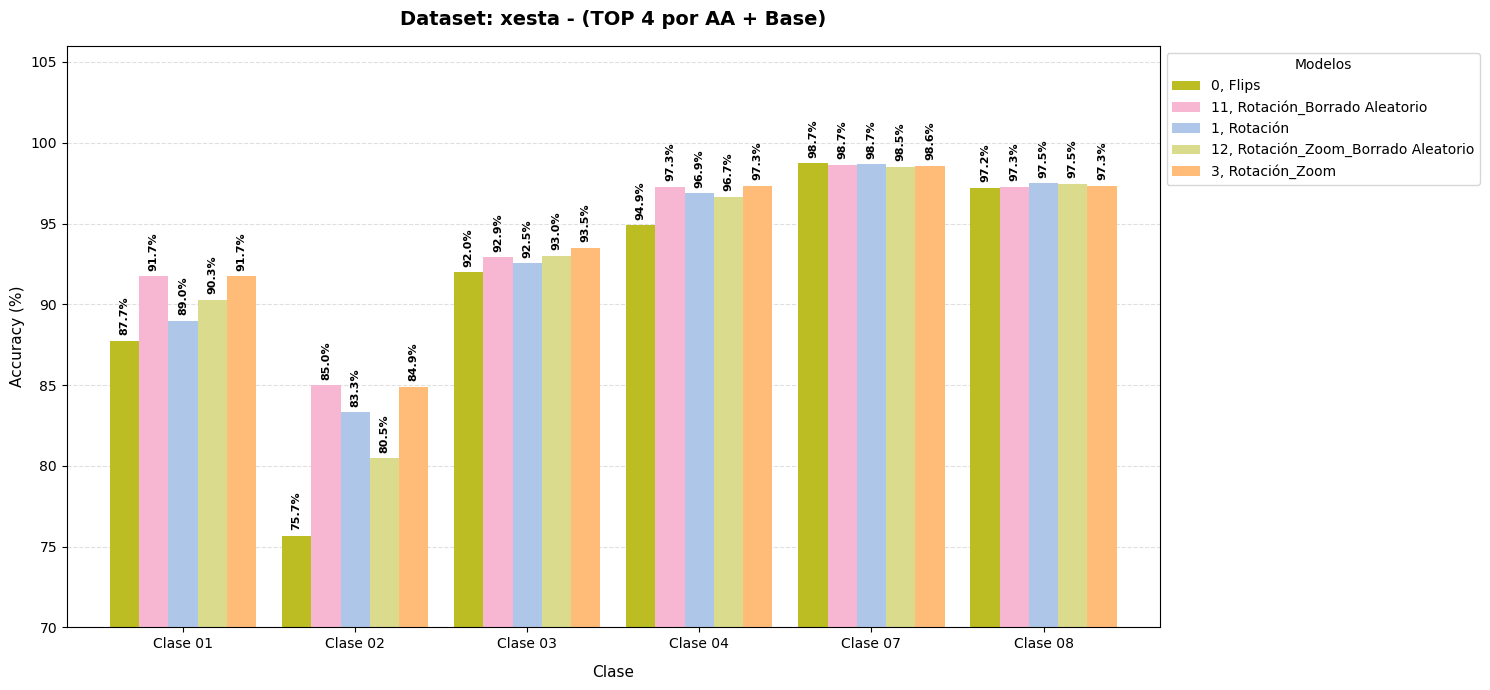

In [7]:
import glob
import math
import os
import matplotlib.pyplot as plt
import pandas as pd


#Graficador por Dataset Individual (Con porcentajes en barras
def graficar_clases_por_dataset(dataset_objetivo, top_7_nombres, ruta_carpeta="resultados_logs"):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    df_clases_metodos = pd.DataFrame()
    aa_por_modelo = {} 

    for archivo in archivos:
        df_res, df_stats, df_clases, nombre_metodo = procesar_log_detallado(archivo)
        
        # Procesamos si el método está en la lista seleccionada
        if nombre_metodo in top_7_nombres:
            if isinstance(df_clases, pd.DataFrame) and dataset_objetivo in df_clases.index:
                df_clases_metodos[nombre_metodo] = df_clases.loc[dataset_objetivo]
                
                # Extraemos el AA Global para ordenar las columnas
                try:
                    valor_aa = df_stats.loc[df_stats['Métrica'] == 'AA Global', 'Media (%)'].values[0]
                    aa_por_modelo[nombre_metodo] = valor_aa
                except:
                    aa_por_modelo[nombre_metodo] = 0

    if df_clases_metodos.empty:
        return

    # Limpieza de datos (ceros y NaNs)
    df_clases_metodos = df_clases_metodos.dropna(how='all')
    df_clases_metodos = df_clases_metodos[(df_clases_metodos > 0).any(axis=1)]

    # ORDENAR COLUMNAS por AA Global de mejor a peor
    modelos_ordenados = sorted(aa_por_modelo, key=aa_por_modelo.get, reverse=True)
    columnas_validas = [m for m in modelos_ordenados if m in df_clases_metodos.columns]
    df_clases_metodos = df_clases_metodos[columnas_validas]

    # CÁLCULO DEL YMIN DINÁMICO (Redondeado a la decena inferior)
    todos_valores = df_clases_metodos.values.flatten()
    valores_validos = [v for v in todos_valores if v > 0 and not pd.isna(v)]
    ymin = (min(valores_validos) // 10) * 10 if valores_validos else 0

    # GENERACIÓN DE GRÁFICA
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Mapeo a la paleta de colores global
    colores_plot = [PALETA_COLORES.get(col, "#d3d3d3") for col in df_clases_metodos.columns]
    
    df_clases_metodos.plot(kind='bar', ax=ax, width=0.85, color=colores_plot)

    # Estética limpia y homogénea
    ax.set_title(f'Dataset: {dataset_objetivo} - (TOP 4 por AA + Base)', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_xlabel('Clase', fontsize=11, labelpad=10)
    
    # Subimos a 106 el límite superior para dar espacio a los números rotados
    ax.set_ylim(ymin, 106) 
    
    # Rejilla sutil detrás de las barras
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.4) 
    
    # AÑADIR PORCENTAJES ENCIMA DE CADA BARRA (Rotados 90° para que no choquen)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=4, fontsize=8, fontweight='semibold', rotation=90)

    # Forzar que los nombres de las clases ("Clase 01", etc.) se lean en horizontal si son cortos
    plt.xticks(rotation=0, ha='center', fontsize=10)
    
    # Leyenda arriba a la derecha por fuera
    ax.legend(title="Modelos", loc='upper left', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


# Orquestador de Filtrado
def ejecutar_graficas_dinamicas_filtradas(ruta_carpeta, top_7_nombres):
    archivos = glob.glob(os.path.join(ruta_carpeta, "*.log"))
    if not archivos: 
        print(f"No se encontraron archivos .log en la ruta: {ruta_carpeta}")
        return
        
    # Obtener nombres de datasets del primer log para saber qué ríos graficar
    _, _, df_clases_ejemplo, _ = procesar_log_detallado(archivos[0])
    
    if isinstance(df_clases_ejemplo, pd.DataFrame):
        datasets_disponibles = df_clases_ejemplo.index.tolist()
        for ds in datasets_disponibles:
            print(f"\nGenerando gráfica detallada para: {ds}...")
            graficar_clases_por_dataset(ds, top_7_nombres, ruta_carpeta)


# BLOQUE DE EJECUCIÓN
ruta_carpeta = "Codigos_AumentadosPyTorch/resultadosAumentado_PyTorch"

if datos_comparacion:
    df_temp = pd.DataFrame(datos_comparacion)
    
    # Obtenemos los nombres de los 4 mejores según el AA Global
    top_4_nombres = df_temp.sort_values(by='AA Global (%)', ascending=False).head(4)['Método'].tolist()
    
    # Buscamos el método que empieza por "0" (el baseline de flips)
    metodos_con_cero = [m for m in df_temp['Método'].unique() if str(m).startswith('0')]
    
    # Combinamos ambas listas sin duplicados
    top_final_nombres = list(dict.fromkeys(top_4_nombres + metodos_con_cero))
    
    print(f"Modelos seleccionados (Top 4 + inicial 0): {top_final_nombres}")

    # Llamamos al orquestador dinámico
    ejecutar_graficas_dinamicas_filtradas(ruta_carpeta, top_final_nombres)